「二季化」検証のためのデータ準備

In [1]:
import os
import numpy as np
import polars as pl
from pathlib import Path
import subprocess
import math
from datetime import datetime, timedelta, date, time
import calendar
JMA_DATA_DIR = Path('/Users/takumi/Projects/MetData/JMA')  # JMAデータ格納ディレクトリのパス

%load_ext autoreload
%autoreload 2
import meteo_lib.core_v4 as cv4
print(cv4.__file__)

#print(isinstance(JMA_DATA_DIR, Path))
      
print("LIB_DATA_DIR     :", cv4.LIB_DATA_DIR)       # 共通マスタ
print("PROJECT_ROOT     :", cv4.PROJECT_ROOT)       # プロジェクトルート
print("PROJECT_DATA_DIR :", cv4.PROJECT_DATA_DIR)   # プロジェクト固有 data
print("OUTPUT_DIR       :", cv4.OUTPUT_DIR)         # 出力
print("JMA_DATA_DIR     :", JMA_DATA_DIR)           # JMAデータ


/Users/takumi/Projects/meteo_lib/meteo_lib/core_v4.py
LIB_DATA_DIR     : /Users/takumi/Projects/meteo_lib/data
PROJECT_ROOT     : /Users/takumi/Projects/analysis-autumn_length
PROJECT_DATA_DIR : /Users/takumi/Projects/analysis-autumn_length/data
OUTPUT_DIR       : /Users/takumi/Projects/analysis-autumn_length/outputs
JMA_DATA_DIR     : /Users/takumi/Projects/MetData/JMA


In [4]:
# JMA daily (monthly parquet) -> daily normals / daily anomaly / moving average / annual mean
# - Assumes station_dir contains YYYY-MM.parquet files.
# - Uses QC codes: keep only 5 or 8 (configurable)
# - Requires: polars, matplotlib (only if you plot)

from __future__ import annotations

from pathlib import Path
import polars as pl

# -----------------------------
# Settings
# -----------------------------
station_name = "仙台"
station_id = "b47590"

RAW_ROOT = Path("/Volumes/Transcend/projects/MetData/JMA")
station_dir = RAW_ROOT / "daily_monthly" / station_id

VALUE_COL1 = "temp_mean"
VALUE_COL2 = "temp_max"
VALUE_COL3 = "temp_min"
QC_OK = (5, 8)

NORMAL_Y0, NORMAL_Y1 = 1991, 2020
TARGET_YEAR = 2025

MA_WINDOW_DAYS = 7  # e.g. 7 or 11  # 移動平均の日数

# -----------------------------
# Load (Lazy)
# -----------------------------
# Keep value + qc + datetime (and optionally max/min if you want later)
cols_needed = [
    "datetime",
    VALUE_COL,
    f"{VALUE_COL}_qc_code",
    VALUE_COL2,
    f"{VALUE_COL2}_qc_code",
    VALUE_COL3,
    f"{VALUE_COL3}_qc_code",
]

lf = (
    pl.scan_parquet(str(station_dir / "*.parquet"), extra_columns="ignore")
    .select(cols_needed)
    .with_columns(
        # Make sure datetime is proper type even if some files differ
        pl.col("datetime").cast(pl.Datetime, strict=False)
    )
)

# -----------------------------
# Helpers
# -----------------------------
def daily_normals_mmdd(
    lf_in: pl.LazyFrame,
    y0: int,
    y1: int,
    value_col: str,
    qc_ok: tuple[int, ...] = (5, 8),
    drop_leapday: bool = True,
) -> pl.DataFrame:
    qc_col = f"{value_col}_qc_code"
    start = pl.datetime(y0, 1, 1)
    end_exclusive = pl.datetime(y1 + 1, 1, 1)

    out = (
        lf_in
        .select(["datetime", value_col, qc_col])
        .filter(pl.col("datetime").is_between(start, end_exclusive, closed="left"))
        .filter(pl.col(qc_col).is_in(list(qc_ok)))
        .filter(pl.col(value_col).is_not_null())
        .with_columns(pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"))
    )

    if drop_leapday:
        out = out.filter(pl.col("mmdd") != "02-29")

    return (
        out
        .group_by("mmdd")
        .agg([
            pl.col(value_col).mean().alias(f"{value_col}_normal_{y0}_{y1}"),
            pl.col(value_col).count().alias("n_valid"),
        ])
        .sort("mmdd")
        .collect()
    )

def daily_obs_year(
    lf_in: pl.LazyFrame,
    year: int,
    value_col: str,
    qc_ok: tuple[int, ...] = (5, 8),
    drop_leapday: bool = True,
) -> pl.DataFrame:
    qc_col = f"{value_col}_qc_code"
    start = pl.datetime(year, 1, 1)
    end_exclusive = pl.datetime(year + 1, 1, 1)

    out = (
        lf_in
        .select(["datetime", value_col, qc_col])
        .filter(pl.col("datetime").is_between(start, end_exclusive, closed="left"))
        .filter(pl.col(qc_col).is_in(list(qc_ok)))
        .filter(pl.col(value_col).is_not_null())
        .with_columns(pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"))
        .sort("datetime")
    )

    if drop_leapday:
        out = out.filter(pl.col("mmdd") != "02-29")

    return out.collect()

# -----------------------------
# 1) 平年値（MM-DD）
# -----------------------------
norm = daily_normals_mmdd(
    lf,
    NORMAL_Y0,
    NORMAL_Y1,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

# -----------------------------
# 2) 観測（ターゲット年） + 日偏差
# -----------------------------
obs = daily_obs_year(
    lf,
    TARGET_YEAR,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

normal_col = f"{VALUE_COL}_normal_{NORMAL_Y0}_{NORMAL_Y1}"

anom = (
    obs
    .join(norm.select(["mmdd", normal_col]), on="mmdd", how="left")
    .with_columns(
        (pl.col(VALUE_COL) - pl.col(normal_col)).alias(f"{VALUE_COL}_anomaly")
    )
    .sort("datetime")
)

# -----------------------------
# 3) 移動平均（例：7日移動平均）
# -----------------------------
anom = anom.with_columns(
    pl.col(f"{VALUE_COL}_anomaly")
    .rolling_mean(window_size=MA_WINDOW_DAYS, min_samples=MA_WINDOW_DAYS)
    .alias(f"{VALUE_COL}_anomaly_ma{MA_WINDOW_DAYS}")
)

# -----------------------------
# 4) 年平均（複数年の時系列）
# -----------------------------
# Example: 1961-2025 annual mean of temp_mean (QC 5/8)
annual = (
    lf
    .select(["datetime", VALUE_COL, f"{VALUE_COL}_qc_code"])
    .filter(pl.col(f"{VALUE_COL}_qc_code").is_in(list(QC_OK)))
    .filter(pl.col(VALUE_COL).is_not_null())
    .with_columns(pl.col("datetime").dt.year().alias("year"))
    .group_by("year")
    .agg([
        pl.col(VALUE_COL).mean().alias(f"{VALUE_COL}_annual_mean"),
        pl.col(VALUE_COL).count().alias("n_valid"),
    ])
    .sort("year")
    .collect()
)

# -----------------------------
# Outputs (print)
# -----------------------------
print("=== 平年値 (head) ===")
print(norm.head(5))

print("\n=== 日偏差+移動平均 (head) ===")
print(anom.select(["datetime", "mmdd", VALUE_COL, normal_col, f"{VALUE_COL}_anomaly", f"{VALUE_COL}_anomaly_ma{MA_WINDOW_DAYS}"]).head(10))

print("\n=== 年平均 (tail) ===")
print(annual.tail(10))

# -----------------------------
# Optional plotting (matplotlib)
# -----------------------------
if False:
    import matplotlib.pyplot as plt

    # Annual mean time series
    plt.figure()
    plt.plot(annual["year"], annual[f"{VALUE_COL}_annual_mean"])
    plt.title(f"{station_name} {VALUE_COL} annual mean (QC {QC_OK})")
    plt.xlabel("Year")
    plt.ylabel(VALUE_COL)
    plt.show()

    # Daily anomaly with moving average (target year)
    plt.figure()
    plt.plot(anom["datetime"], anom[f"{VALUE_COL}_anomaly"], label="anomaly")
    plt.plot(anom["datetime"], anom[f"{VALUE_COL}_anomaly_ma{MA_WINDOW_DAYS}"], label=f"MA{MA_WINDOW_DAYS}")
    plt.title(f"{station_name} {TARGET_YEAR} daily anomaly vs normals ({NORMAL_Y0}-{NORMAL_Y1})")
    plt.xlabel("Date")
    plt.ylabel(VALUE_COL)
    plt.legend()
    plt.show()

=== 平年値 (head) ===
shape: (5, 3)
┌───────┬────────────────────────────┬─────────┐
│ mmdd  ┆ temp_mean_normal_1991_2020 ┆ n_valid │
│ ---   ┆ ---                        ┆ ---     │
│ str   ┆ f32                        ┆ u32     │
╞═══════╪════════════════════════════╪═════════╡
│ 01-01 ┆ 2.63                       ┆ 30      │
│ 01-02 ┆ 2.923333                   ┆ 30      │
│ 01-03 ┆ 2.73                       ┆ 30      │
│ 01-04 ┆ 2.61                       ┆ 30      │
│ 01-05 ┆ 2.393333                   ┆ 30      │
└───────┴────────────────────────────┴─────────┘

=== 日偏差+移動平均 (head) ===
shape: (10, 6)
┌──────────────┬───────┬───────────┬─────────────────────┬────────────────────┬────────────────────┐
│ datetime     ┆ mmdd  ┆ temp_mean ┆ temp_mean_normal_19 ┆ temp_mean_anomaly  ┆ temp_mean_anomaly_ │
│ ---          ┆ ---   ┆ ---       ┆ 91_2020             ┆ ---                ┆ ma7                │
│ datetime[μs] ┆ str   ┆ f32       ┆ ---                 ┆ f32                ┆ ---  

In [8]:
norm_1990 = daily_normals_mmdd(
    lf,
    1961,
    1990,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

norm_2020 = daily_normals_mmdd(
    lf,
    1991,
    2020,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

print(norm_1990.head())
print(norm_2020.head())

shape: (5, 3)
┌───────┬────────────────────────────┬─────────┐
│ mmdd  ┆ temp_mean_normal_1961_1990 ┆ n_valid │
│ ---   ┆ ---                        ┆ ---     │
│ str   ┆ f32                        ┆ u32     │
╞═══════╪════════════════════════════╪═════════╡
│ 01-01 ┆ 1.85                       ┆ 30      │
│ 01-02 ┆ 1.696667                   ┆ 30      │
│ 01-03 ┆ 1.21                       ┆ 30      │
│ 01-04 ┆ 1.533333                   ┆ 30      │
│ 01-05 ┆ 1.443333                   ┆ 30      │
└───────┴────────────────────────────┴─────────┘
shape: (5, 3)
┌───────┬────────────────────────────┬─────────┐
│ mmdd  ┆ temp_mean_normal_1991_2020 ┆ n_valid │
│ ---   ┆ ---                        ┆ ---     │
│ str   ┆ f32                        ┆ u32     │
╞═══════╪════════════════════════════╪═════════╡
│ 01-01 ┆ 2.63                       ┆ 30      │
│ 01-02 ┆ 2.923333                   ┆ 30      │
│ 01-03 ┆ 2.73                       ┆ 30      │
│ 01-04 ┆ 2.61                       ┆ 30

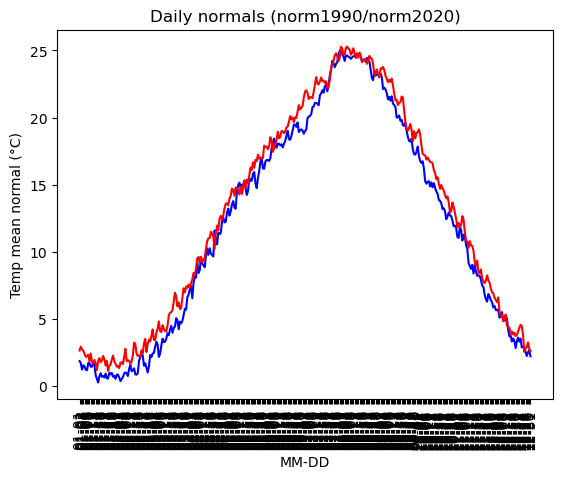

In [11]:
import matplotlib.pyplot as plt

plt.plot(norm_1990["mmdd"], norm_1990["temp_mean_normal_1961_1990"], color="blue")
plt.plot(norm_2020["mmdd"], norm_2020["temp_mean_normal_1991_2020"], color="red")
plt.xlabel("MM-DD")
plt.ylabel("Temp mean normal (°C)")
plt.title("Daily normals (norm1990/norm2020)")
plt.xticks(rotation=90)
plt.show()